In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q pillow opencv-python tqdm
!pip install -q grad-cam wandb streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 118.9 MB/s eta 0:00:00


In [3]:
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
from PIL import Image
import cv2
import tqdm
import wandb
import streamlit

print("===== MediScan Environment =====")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("================================")
print("All libraries imported successfully!")

===== MediScan Environment =====
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
OpenCV: 4.14.0
CUDA: True
GPU: Tesla T4
All libraries imported successfully!


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

PROJECT_PATH = "/content/drive/MyDrive/MediScan"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("MediScan project path:")
print(PROJECT_PATH)

MediScan project path:
/content/drive/MyDrive/MediScan


In [7]:
DATA_PATH = os.path.join(PROJECT_PATH, "data")

os.makedirs(DATA_PATH, exist_ok=True)

print("Data folder:")
print(DATA_PATH)

Data folder:
/content/drive/MyDrive/MediScan/data


In [8]:
print("MediScan contents:")
print(os.listdir(PROJECT_PATH))

MediScan contents:
['Data', 'best_model.keras', 'best_model_v2.keras', 'best_model_v3.keras', 'data']


In [9]:
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

print("Contents of data folder:")
print(os.listdir(DATA_PATH))

Contents of data folder:
[]


In [10]:
import os

OLD_DATA_PATH = "/content/drive/MyDrive/MediScan/Data"

print("Contents of old Data folder:")
print(os.listdir(OLD_DATA_PATH))

Contents of old Data folder:
['archive.zip', 'Testing', 'Training']


In [11]:
import shutil
import os

OLD_DATA_PATH = "/content/drive/MyDrive/MediScan/Data"
NEW_DATA_PATH = "/content/drive/MyDrive/MediScan/data"

# Copy Training
shutil.copytree(
    os.path.join(OLD_DATA_PATH, "Training"),
    os.path.join(NEW_DATA_PATH, "Training"),
    dirs_exist_ok=True
)

# Copy Testing
shutil.copytree(
    os.path.join(OLD_DATA_PATH, "Testing"),
    os.path.join(NEW_DATA_PATH, "Testing"),
    dirs_exist_ok=True
)

print("Dataset copied successfully!")

Dataset copied successfully!


In [12]:
print("Contents of new data folder:")
print(os.listdir(NEW_DATA_PATH))

Contents of new data folder:
['Training', 'Testing']


In [13]:
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

train_path = os.path.join(DATA_PATH, "Training")
test_path = os.path.join(DATA_PATH, "Testing")

train_classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

test_classes = sorted([
    folder for folder in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, folder))
])

print("Training classes:", train_classes)
print("Testing classes:", test_classes)

print("\nNumber of training classes:", len(train_classes))
print("Number of testing classes:", len(test_classes))

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Number of training classes: 4
Number of testing classes: 4


In [14]:
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/MediScan/data")

for split in ["Training", "Testing"]:
    print(f"\n{'=' * 40}")
    print(f"{split} Dataset")
    print(f"{'=' * 40}")

    split_path = DATA_PATH / split
    total = 0

    for class_name in sorted(os.listdir(split_path)):
        class_path = split_path / class_name

        if class_path.is_dir():
            image_count = len([
                file for file in class_path.iterdir()
                if file.is_file()
            ])

            total += image_count

            print(f"{class_name:<15}: {image_count}")

    print(f"{'-' * 40}")
    print(f"Total{'':<9}: {total}")


Training Dataset
glioma         : 1400
meningioma     : 1400
notumor        : 1400
pituitary      : 1400
----------------------------------------
Total         : 5600

Testing Dataset
glioma         : 400
meningioma     : 400
notumor        : 400
pituitary      : 400
----------------------------------------
Total         : 1600


Image name: Tr-gl_1.jpg
Image size: (512, 512)
Image mode: L


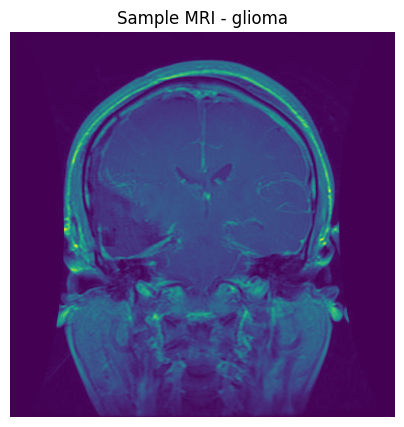

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

sample_class = "glioma"

class_path = os.path.join(
    DATA_PATH,
    "Training",
    sample_class
)

# Get the first image
image_name = sorted(os.listdir(class_path))[0]
image_path = os.path.join(class_path, image_name)

# Open image
image = Image.open(image_path)

print("Image name:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"Sample MRI - {sample_class}")
plt.axis("off")
plt.show()

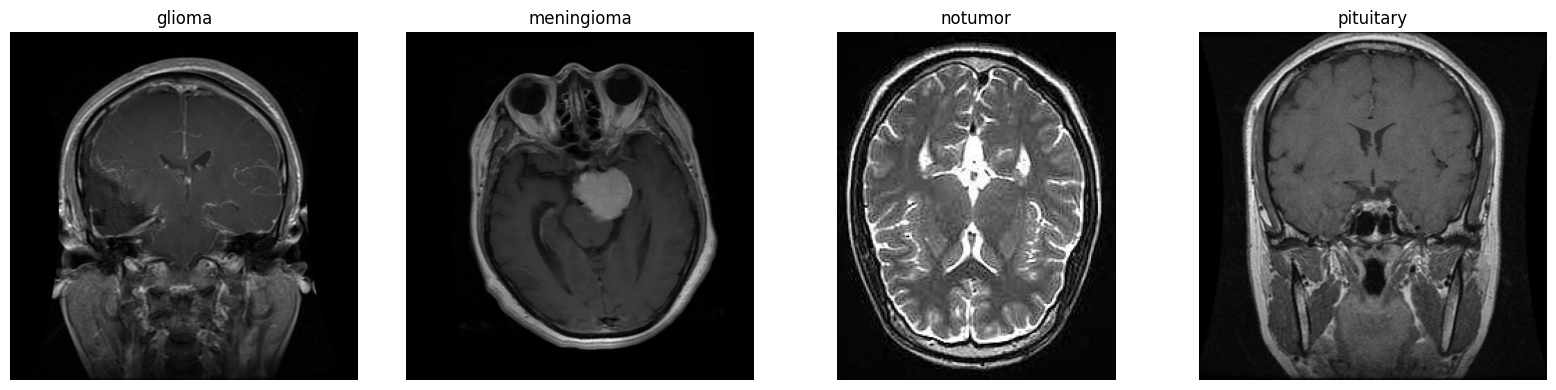

In [16]:
from PIL import Image
import matplotlib.pyplot as plt
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

classes = ["glioma", "meningioma", "notumor", "pituitary"]

plt.figure(figsize=(16, 4))

for i, class_name in enumerate(classes):

    class_path = os.path.join(
        DATA_PATH,
        "Training",
        class_name
    )

    image_name = sorted(os.listdir(class_path))[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from PIL import Image
from collections import Counter
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

image_sizes = Counter()

for split in ["Training", "Testing"]:
    split_path = os.path.join(DATA_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                try:
                    with Image.open(image_path) as img:
                        image_sizes[img.size] += 1
                except:
                    pass

print("Unique image dimensions:")
for size, count in image_sizes.most_common():
    print(f"{size}: {count} images")

print("\nTotal images checked:", sum(image_sizes.values()))

Unique image dimensions:
(512, 512): 5014 images
(225, 225): 338 images
(630, 630): 90 images
(201, 251): 57 images
(228, 221): 51 images
(232, 217): 50 images
(442, 442): 48 images
(236, 236): 48 images
(150, 198): 44 images
(200, 252): 43 images
(428, 417): 42 images
(227, 222): 39 images
(173, 201): 36 images
(206, 244): 35 images
(256, 256): 33 images
(192, 192): 31 images
(201, 250): 29 images
(218, 231): 29 images
(215, 234): 28 images
(227, 262): 27 images
(208, 242): 24 images
(468, 444): 24 images
(504, 540): 23 images
(359, 449): 23 images
(214, 236): 22 images
(300, 168): 21 images
(400, 442): 20 images
(236, 213): 19 images
(393, 400): 18 images
(207, 243): 18 images
(276, 326): 17 images
(230, 282): 17 images
(442, 454): 17 images
(441, 442): 16 images
(235, 214): 16 images
(550, 664): 16 images
(194, 259): 15 images
(680, 680): 15 images
(420, 280): 14 images
(339, 340): 13 images
(212, 238): 12 images
(275, 183): 12 images
(380, 530): 12 images
(196, 257): 12 images
(642

In [18]:
from PIL import Image
import os

DATA_PATH = "/content/drive/MyDrive/MediScan/data"

corrupted_images = []

for split in ["Training", "Testing"]:
    split_path = os.path.join(DATA_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception as e:
                corrupted_images.append(image_path)

print("Total corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for path in corrupted_images:
        print(path)
else:
    print("All images are valid!")

Total corrupted images: 0
All images are valid!


In [19]:
dataset_info = {
    "total_images": 7200,
    "training_images": 5600,
    "testing_images": 1600,
    "num_classes": 4,
    "classes": [
        "glioma",
        "meningioma",
        "notumor",
        "pituitary"
    ],
    "corrupted_images": 0,
    "image_mode": "Grayscale",
    "main_image_size": "512x512",
    "target_size": "224x224"
}

print("===== MediScan Day 1 Dataset Summary =====")

for key, value in dataset_info.items():
    print(f"{key}: {value}")

print("\nDay 1 dataset verification completed successfully! ✅")

===== MediScan Day 1 Dataset Summary =====
total_images: 7200
training_images: 5600
testing_images: 1600
num_classes: 4
classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
corrupted_images: 0
image_mode: Grayscale
main_image_size: 512x512
target_size: 224x224

Day 1 dataset verification completed successfully! ✅
